In [2]:
import pandas as pd

df = pd.read_csv("../datasets/raw/aqi/aqi_india_38cols_knn_final.csv")

print(df.head())

print(df.shape)

print(df.columns.tolist())

ModuleNotFoundError: No module named 'pandas'

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
df = pd.read_csv("../datasets/raw/aqi/aqi_india_38cols_knn_final.csv")

In [3]:
df.head()

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi,aqi_category,pm25_category_india,festival_period,crop_burning_season
0,agartala,tripura,23.8315,91.2868,2022-08-05 00:00:00,8.0,friday,False,monsoon,night,...,21.8,2.7,32.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
1,agartala,tripura,23.8315,91.2868,2022-08-05 01:00:00,8.0,friday,False,monsoon,night,...,18.5,3.0,33.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
2,agartala,tripura,23.8315,91.2868,2022-08-05 02:00:00,8.0,friday,False,monsoon,night,...,15.1,3.3,34.0,0.0,0.15,54.0,Moderate,good,False,False
3,agartala,tripura,23.8315,91.2868,2022-08-05 03:00:00,8.0,friday,False,monsoon,night,...,14.1,3.3,32.0,0.0,0.15,54.0,Moderate,good,False,False
4,agartala,tripura,23.8315,91.2868,2022-08-05 04:00:00,8.0,friday,False,monsoon,night,...,13.9,3.2,30.0,0.0,0.14,54.0,Moderate,good,False,False


In [6]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   city                 842160 non-null  str    
 1   state                842160 non-null  str    
 2   latitude             842160 non-null  float64
 3   longitude            842160 non-null  float64
 4   datetime             842160 non-null  str    
 5   month                842160 non-null  float64
 6   day_name             842160 non-null  str    
 7   is_weekend           842160 non-null  bool   
 8   season               842160 non-null  str    
 9   time_of_day          842160 non-null  str    
 10  humidity_percent     842160 non-null  float64
 11  dew_point_c          842160 non-null  float64
 12  wind_gusts_kmh       842160 non-null  float64
 13  precipitation_mm     842160 non-null  float64
 14  is_raining           842160 non-null  bool   
 15  heavy_rain           842160 

city                   0
state                  0
latitude               0
longitude              0
datetime               0
month                  0
day_name               0
is_weekend             0
season                 0
time_of_day            0
humidity_percent       0
dew_point_c            0
wind_gusts_kmh         0
precipitation_mm       0
is_raining             0
heavy_rain             0
pressure_msl_hpa       0
cloud_cover_percent    0
pm2_5_ugm3             0
pm10_ugm3              0
co_ugm3                0
no2_ugm3               0
so2_ugm3               0
o3_ugm3                0
dust_ugm3              0
aod                    0
us_aqi                 0
aqi_category           0
pm25_category_india    2
festival_period        0
crop_burning_season    0
dtype: int64

<Axes: >

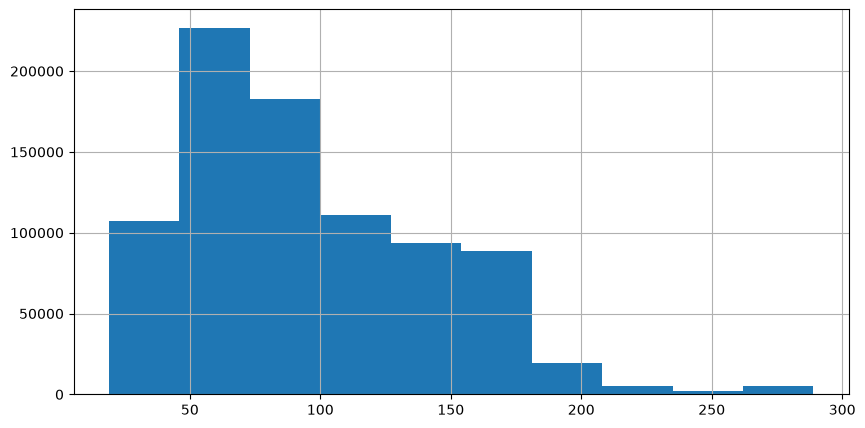

In [7]:
df["us_aqi"].hist(figsize=(10,5))

<Axes: >

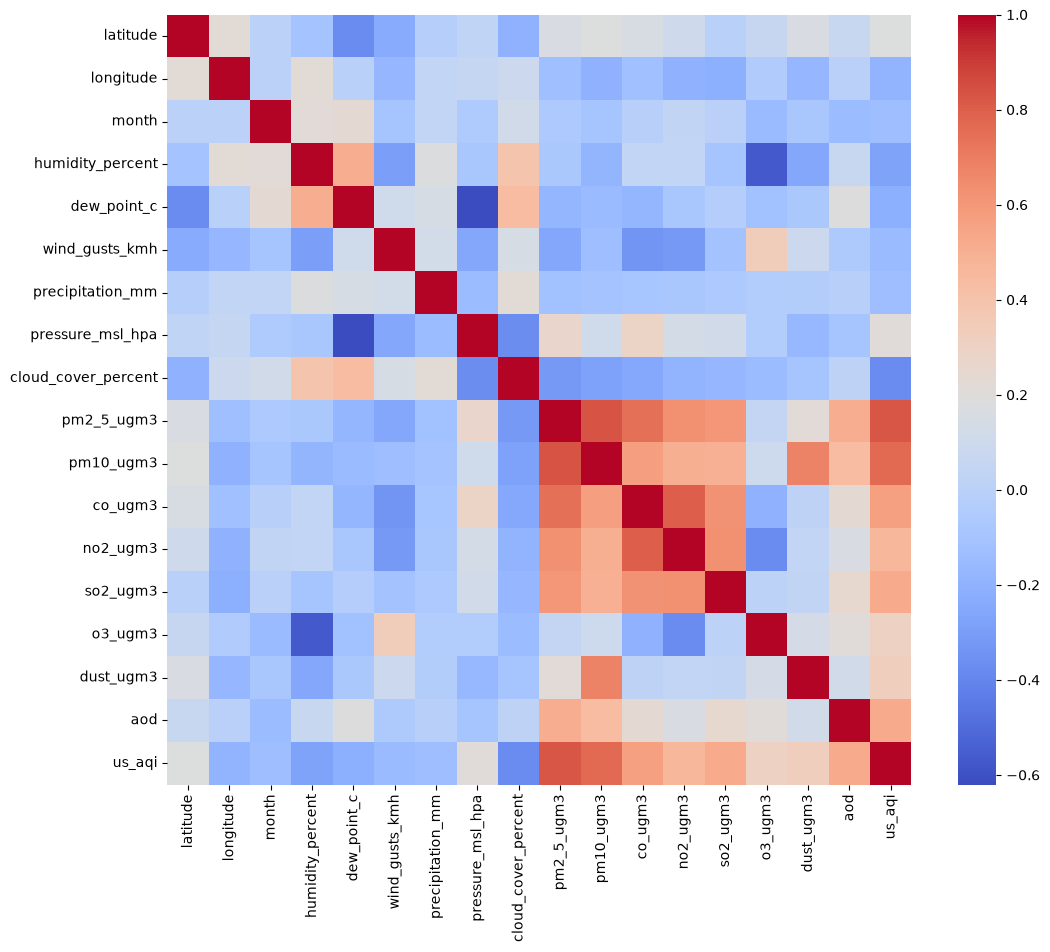

In [8]:
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,10))

sns.heatmap(corr,cmap="coolwarm")

In [9]:
df = pd.read_csv("../datasets/raw/aqi/aqi_india_38cols_knn_final.csv")

print(df.shape)
print(df.head())

(842160, 31)
       city    state  latitude  longitude             datetime  month  \
0  agartala  tripura   23.8315    91.2868  2022-08-05 00:00:00    8.0   
1  agartala  tripura   23.8315    91.2868  2022-08-05 01:00:00    8.0   
2  agartala  tripura   23.8315    91.2868  2022-08-05 02:00:00    8.0   
3  agartala  tripura   23.8315    91.2868  2022-08-05 03:00:00    8.0   
4  agartala  tripura   23.8315    91.2868  2022-08-05 04:00:00    8.0   

  day_name  is_weekend   season time_of_day  ...  no2_ugm3  so2_ugm3  o3_ugm3  \
0   friday       False  monsoon       night  ...      21.8       2.7     32.0   
1   friday       False  monsoon       night  ...      18.5       3.0     33.0   
2   friday       False  monsoon       night  ...      15.1       3.3     34.0   
3   friday       False  monsoon       night  ...      14.1       3.3     32.0   
4   friday       False  monsoon       night  ...      13.9       3.2     30.0   

   dust_ugm3   aod  us_aqi    aqi_category  pm25_category_ind

In [10]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [11]:
df = df.sort_values(["city", "datetime"])


In [12]:
df["target_aqi"] = df.groupby("city")["us_aqi"].shift(-1)

In [13]:
df = df.dropna(subset=["target_aqi"])